# Example EOCIS Kerchunk Dataset

The following is an example for how to access the new EOCIS kerchunk aggregations.

## Single Kerchunk Aggregation - Full Time Series
#### EOCIS AEROSOL from Sentinel 3A daily - Aggregated Item (01/05/2016 - 31/12/2024)

In [ ]:
import pystac_client
url = "https://api.stac.ceda.ac.uk/"

client = pystac_client.Client.open(url)
# aggregation=true to get ONLY the aggregation item(s)
search = client.search(collections=['eocis-aerosol-slstr-daily-s3a'], query=['aggregation=true'])

In [4]:
for item in search.items():
    print(item.id)

20160501-20241231_AEROSOL-AER-PRODUCTS-SLSTR-SENTINEL-S3A-SU-DAILY-v1.14.1


This single item has the aggregation as the reference file asset. We can view the properties of this item as below:

In [6]:
item.assets['reference_file']

<Asset href=https://dap.ceda.ac.uk/neodc/eocis/metadata/kerchunk/aggregations/20160501-20241231_AEROSOL-AER-PRODUCTS-SLSTR-SENTINEL-S3A-SU-DAILY-v1.14.1.kr1.0.json>

In [10]:
item.properties

{'title': 'EOCIS AEROSOL from Sentinel 3A daily - Aggregated Item (01/05/2016 - 31/12/2024)',
 'description': 'This dataset contains the level-3 daily mean aerosol properties products from Sentinel-3A SLSTR satellite observations. Data are processed using the Swansea University algorithm',
 'datetime': None,
 'created': '2026-03-24T09:58:19Z',
 'updated': '2026-03-24T10:01:24.869814Z',
 'start_datetime': '2016-05-01T00:00:00Z',
 'end_datetime': '2024-12-31T00:00:00Z',
 'license': 'cc-by-4.0',
 'platform': 'SENTINEL-S3A',
 'instruments': ['SLSTR'],
 'cube:variables': {'pixel_count': {'unit': '1',
   'description': 'number of retrieval pixels in grid cell',
   'type': 'data',
   'dimensions': ['time', 'latitude', 'longitude']},
  'AOD550_mean': {'unit': '1',
   'description': 'aerosol optical thickness at 550 nm',
   'type': 'data',
   'dimensions': ['time', 'latitude', 'longitude']},
  'AOD550_sdev': {'unit': '1',
   'description': 'standard deviation aerosol optical thickness at 550 nm

Note the disclaimer on the aggregation item, which lets us know for this dataset that the aggregation uses a 'Virtual' dimension that doesn't exist in the source files.

In [12]:
print(item.properties['disclaimer'])

Aggregated Item generated using CEDA-PADOCC workflow. This aggregation uses a "Virtual" time dimension not present in the original NetCDF data.


We can now open the `reference_file` asset from this item:

In [17]:
import xarray as xr
asset = item.assets['reference_file'].to_dict()
ds = xr.open_dataset(asset['href'], **asset['xarray:open_kwargs'])

The above syntax can be used for most aggregation assets. All EOCIS aggregation assets contain an `xarray:open_kwargs` property that includes the `engine` parameter as well as additional parameters to ensure the dataset is loaded properly.

The dataset we have loaded contains all timesteps across the global dataset for each variable. This takes some time to load initially as the kerchunk file is downloaded and interpreted into a set of Dask arrays. Once the initial load is done however, dataset array operations should perform very efficiently using lazy loading in Dask.

In [19]:
ds

<xarray.Dataset> Size: 32GB
Dimensions:                   (time: 3108, latitude: 180, longitude: 360)
Coordinates:
  * latitude                  (latitude) float32 720B -89.5 -88.5 ... 88.5 89.5
  * longitude                 (longitude) float32 1kB -179.5 -178.5 ... 179.5
  * time                      (time) datetime64[ns] 25kB 2016-05-01 ... 2024-...
Data variables: (12/39)
    AAOD550_mean              (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    AAOD550_sdev              (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ANG550_870_mean           (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ANG550_870_sdev           (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    AOD1600_mean              (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    AOD1600_sdev              (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...                        ...
    D_AOD550_sdev             (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    FM_AOD550_mean            (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    FM_AOD550_sdev            (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    SSA550_mean               (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    SSA550_sdev               (time, latitude, longitude) float32 806MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    pixel_count               (time, latitude, longitude) float64 2GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes: (12/41)
    Conventions:                CF-1.6
    tracking_id:                52bbeae2-b4f2-4b3d-9aba-95a7d089fd5b
    naming_authority:           uk.ac.su.aatsraerosol
    sensor:                     SLSTR
    platform:                   SENTINEL-S3A
    resolution:                 1x1 degrees
    ...                         ...
    history:                    Level 3 product generated using Swansea Unive...
    license:                    Creative Commons Attribution 4.0  https://cre...
    inputfilelist:              20160501211410-C3S-L3C_AEROSOL-AER_PRODUCTS-S...
    acknowledgement:            The European Space Agency (ESA) funded the de...
    format_version:             EOCIS Data Standards v1.0
    disclaimer:                 This aggregation file was produced by combini...

In [ ]:
july_AOD = ds.AOD1600_mean.sel(time=slice('2017-07-01','2017-07-31'))
july_AOD

<xarray.DataArray 'AOD1600_mean' (time: 29, latitude: 180, longitude: 360)> Size: 8MB
dask.array<getitem, shape=(29, 180, 360), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * time       (time) datetime64[ns] 232B 2017-07-01 2017-07-02 ... 2017-07-29
Attributes:
    long_name:      aerosol optical thickness at 1600 nm
    standard_name:  atmosphere_optical_thickness_due_to_ambient_aerosol
    units:          1
    valid_range:    [0.0, 4.0]

In [22]:
july_mean = july_AOD.mean(dim='time').mean(dim='longitude')

## Example Plot: Average Aerosol Optical Thickness (1600nm) for July 2017 per latitude.

The example plot shows a peak in AOD1600 in July at ~20 degrees North, with a second smaller peak at ~60 degrees North.

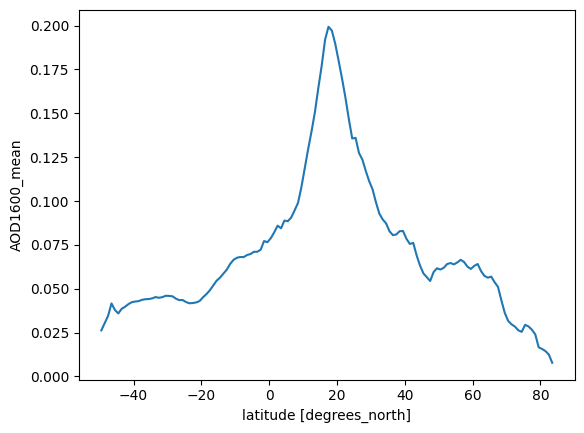

In [23]:
july_mean.plot()

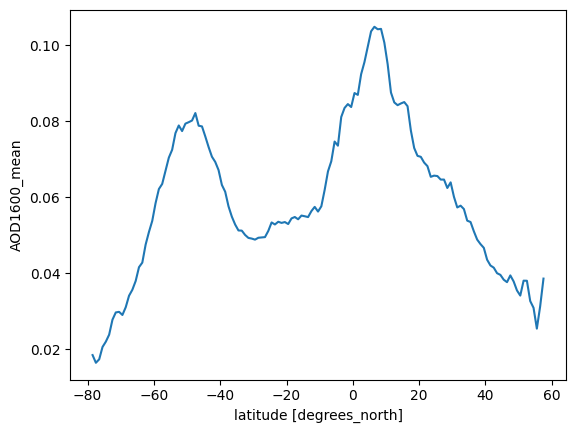

In [24]:
jan_mean = ds.AOD1600_mean.sel(time=slice('2017-01-01','2017-01-31'))
jan_mean.mean(dim='time').mean(dim='longitude').plot()

Comparing the Jan/July plots we see the January peaks are roughly half the intensity of the July values, with an additional peak at ~50 degrees South. These graphs can be compared to other sets of data to determine the likely reasons for these fluctuations.